# Saudi Real Estate Price and Market Indicators (2020–2025)

Deep-dive into price trends, property type distribution, and regional
market activity derived from MOJ sales records.

**Data source:** MOJ Open Data Portal — Sales files 2020-Q1 to 2025-Q4
**Units:** Prices in SAR; area in m²


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Arabic font setup ──────────────────────────────────────────────────────
import matplotlib.font_manager as fm

ARABIC_FONTS = ['DIN Next LT Arabic', '.SF Arabic Rounded', 'Arial Unicode MS', 'Arial']
chosen_font = None
available = {f.name for f in fm.fontManager.ttflist}
for candidate in ARABIC_FONTS:
    if candidate in available:
        chosen_font = candidate
        break

if chosen_font:
    plt.rcParams['font.family'] = chosen_font

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

NB_DIR = Path('.')
SALES_DIR = Path('../moj/sales')


In [2]:
# ── Load and clean all MOJ Sales files ────────────────────────────────────
# Note: 2023-Q1 uses a different schema — normalised on load.

def load_sales_file(fpath, year, q):
    """Load one quarter CSV and normalise to standard columns."""
    df_q = pd.read_csv(fpath, encoding='utf-8-sig')
    df_q.columns = df_q.columns.str.strip('\ufeff').str.strip()
    if 'السعر بالريال السعودي' in df_q.columns:
        df_q = df_q.rename(columns={'السعر بالريال السعودي': 'السعر'})
    if 'تصنيف العقار' not in df_q.columns:
        df_q['تصنيف العقار'] = 'غير محدد'
    if 'المنطقة' not in df_q.columns:
        return None
    if 'المساحة' not in df_q.columns:
        df_q['المساحة'] = None
    keep = ['المنطقة', 'تصنيف العقار', 'السعر', 'المساحة']
    df_q = df_q[[c for c in keep if c in df_q.columns]].copy()
    df_q['year']    = year
    df_q['quarter'] = q
    return df_q

def clean_numeric(series):
    return pd.to_numeric(
        series.astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )

frames = []
for year in range(2020, 2026):
    for q in range(1, 5):
        fpath = SALES_DIR / f'MOJ-Sales-{year}-Q{q}.csv'
        if not fpath.exists():
            continue
        df_q = load_sales_file(fpath, year, q)
        if df_q is not None:
            frames.append(df_q)

df = pd.concat(frames, ignore_index=True)

df['السعر']   = clean_numeric(df['السعر'])
df['المساحة'] = clean_numeric(df['المساحة'])

# Filter out bad rows
df = df[df['السعر'].notna() & (df['السعر'] > 0)]
df = df[df['المساحة'].notna() & (df['المساحة'] > 0)]

# Price per m²
df['price_per_m2'] = df['السعر'] / df['المساحة']

# Remove extreme outliers (top/bottom 1%)
lo = df['price_per_m2'].quantile(0.01)
hi = df['price_per_m2'].quantile(0.99)
df = df[(df['price_per_m2'] >= lo) & (df['price_per_m2'] <= hi)]

df['year_quarter'] = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)
yq_order = sorted(df['year_quarter'].unique())

print(f"Rows after cleaning: {len(df):,}")
print(f"Price per m² range: {lo:,.0f} – {hi:,.0f} SAR/m²")

# ── Group by year+quarter and region ─────────────────────────────────────
agg = (
    df.groupby(['year_quarter', 'year', 'quarter', 'المنطقة'])
      .agg(
          median_price    = ('السعر',      'median'),
          median_area     = ('المساحة',    'median'),
          median_ppm2     = ('price_per_m2','median'),
          count           = ('السعر',      'size'),
      )
      .reset_index()
)
print(f"\nAggregated rows: {len(agg):,}")


Rows after cleaning: 1,378,975
Price per m² range: 2 – 9,521 SAR/m²

Aggregated rows: 312


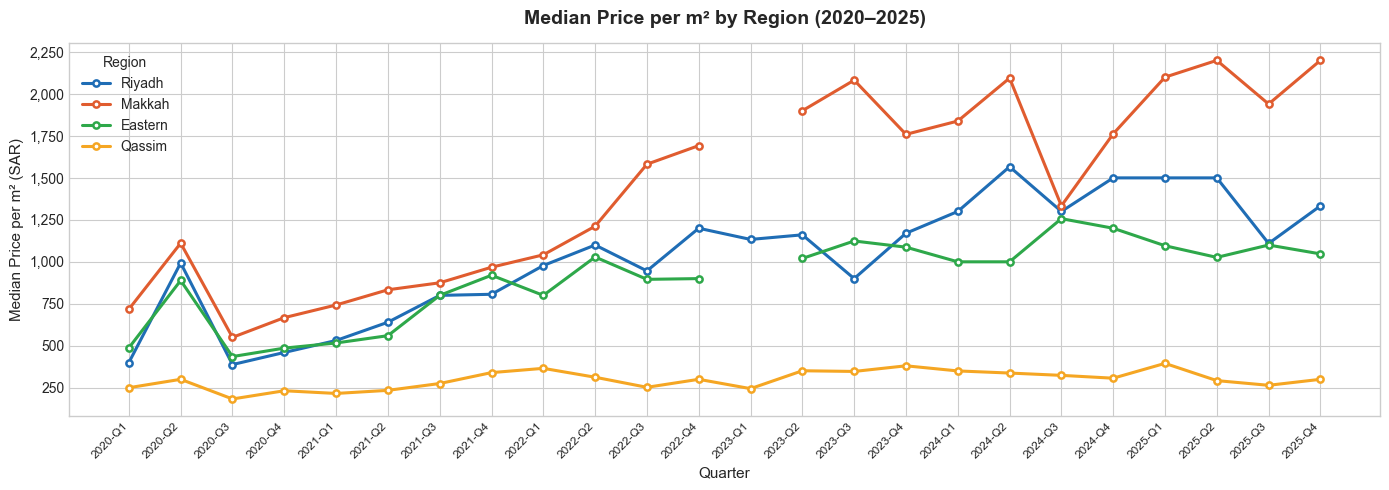

Saved → chart_price_per_m2.png


In [3]:
# ── Chart 4: Median price per m² over time — top 4 regions ────────────────

TARGET_REGIONS = [
    'منطقة الرياض',
    'منطقة مكة المكرمه',
    'منطقة الشرقية',
    'منطقة القصيم',
]
REGION_LABELS = {
    'منطقة الرياض':        'Riyadh',
    'منطقة مكة المكرمه':   'Makkah',
    'منطقة الشرقية':       'Eastern',
    'منطقة القصيم':        'Qassim',
}
REGION_COLORS = {
    'منطقة الرياض':        '#1f6db5',
    'منطقة مكة المكرمه':   '#e05c2f',
    'منطقة الشرقية':       '#2ea84a',
    'منطقة القصيم':        '#f5a623',
}

fig, ax = plt.subplots(figsize=(14, 5))

for region in TARGET_REGIONS:
    sub = (
        agg[agg['المنطقة'] == region]
           .set_index('year_quarter')['median_ppm2']
           .reindex(yq_order)
    )
    ax.plot(yq_order, sub.values,
            label=REGION_LABELS[region],
            color=REGION_COLORS[region],
            linewidth=2.2, marker='o', markersize=4.5,
            markerfacecolor='white', markeredgewidth=1.8)

ax.set_title('Median Price per m² by Region (2020–2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Quarter', fontsize=11)
ax.set_ylabel('Median Price per m² (SAR)', fontsize=11)
ax.set_xticks(range(len(yq_order)))
ax.set_xticklabels(yq_order, rotation=45, ha='right', fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Region', fontsize=10, title_fontsize=10)

plt.tight_layout()
out4 = NB_DIR / 'chart_price_per_m2.png'
fig.savefig(out4, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out4}")


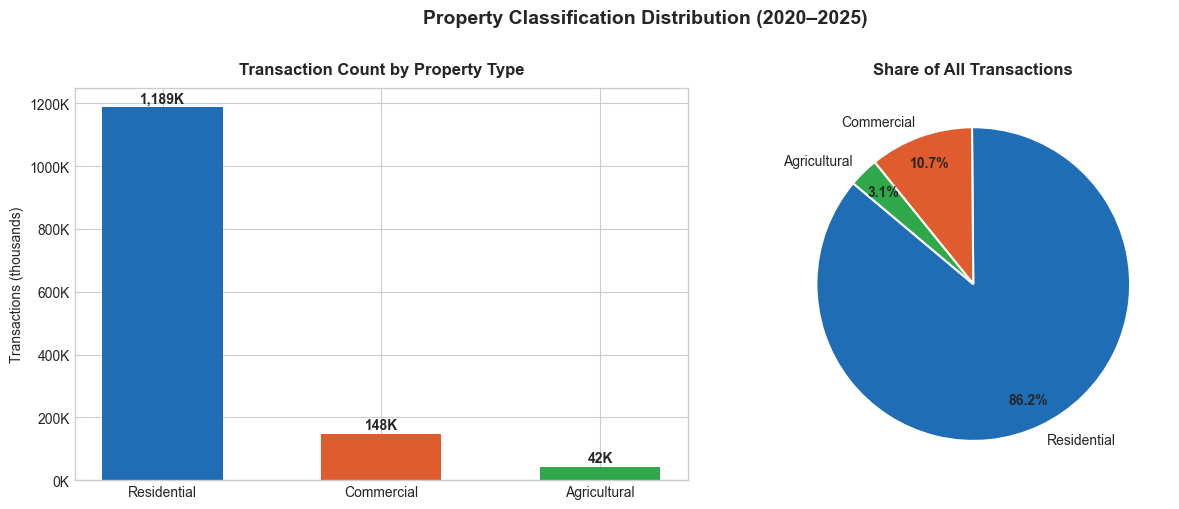

Saved → chart_classification.png


In [4]:
# ── Chart 5: Property classification distribution ─────────────────────────

CLASS_LABELS = {
    'سكني':       'Residential',
    'تجاري':      'Commercial',
    'زراعي':      'Agricultural',
    'صناعي':      'Industrial',
    'غير محدد':   'Unclassified',
    'أخرى':       'Other',
}

# Map to English, keep only known categories
df['class_en'] = df['تصنيف العقار'].map(CLASS_LABELS).fillna('Other')
class_counts = df['class_en'].value_counts()
# Filter out tiny categories for cleaner chart
class_counts = class_counts[class_counts > 100]
labels_en = class_counts.index.tolist()

COLORS = ['#1f6db5', '#e05c2f', '#2ea84a']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ─── Left: bar chart by classification ───────────────────────────────────
bars = axes[0].bar(labels_en,
                   class_counts.values / 1_000,
                   color=COLORS[:len(class_counts)],
                   width=0.55, edgecolor='none')

for bar, val in zip(bars, class_counts.values / 1_000):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 f'{val:,.0f}K',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_title('Transaction Count by Property Type', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('Transactions (thousands)', fontsize=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))

# ─── Right: pie chart ─────────────────────────────────────────────────────
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=labels_en,
    autopct='%1.1f%%',
    colors=COLORS[:len(class_counts)],
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

axes[1].set_title('Share of All Transactions', fontsize=12, fontweight='bold', pad=10)

fig.suptitle('Property Classification Distribution (2020–2025)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
out5 = NB_DIR / 'chart_classification.png'
fig.savefig(out5, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out5}")


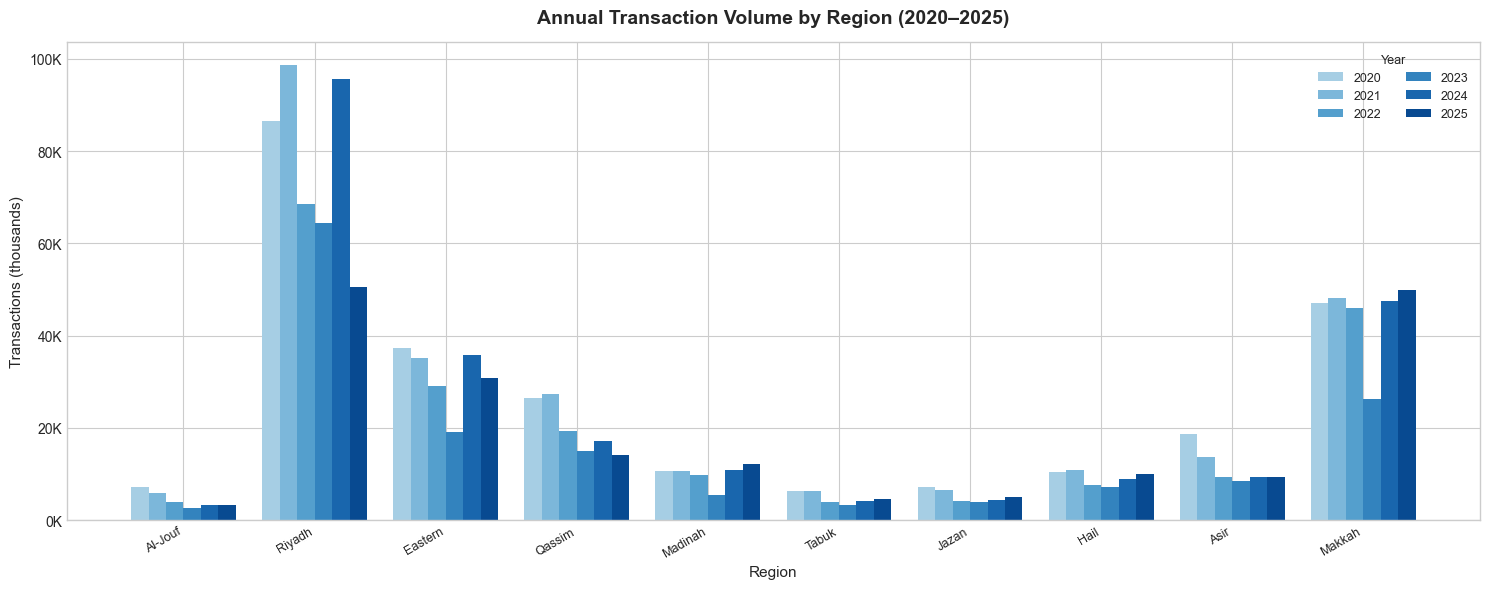

Saved → chart_region_year_heatmap.png


In [5]:
# ── Chart 6: Transaction count heatmap — region × year ────────────────────

# Pick top 10 regions by total volume
top10 = (
    df.groupby('المنطقة')
      .size()
      .nlargest(10)
      .index
      .tolist()
)

pivot_hm = (
    df[df['المنطقة'].isin(top10)]
      .groupby(['المنطقة', 'year'])
      .size()
      .unstack(fill_value=0)
)

# English labels for regions
REGION_EN = {
    'منطقة الرياض':           'Riyadh',
    'منطقة مكة المكرمه':      'Makkah',
    'منطقة الشرقية':          'Eastern',
    'منطقة القصيم':           'Qassim',
    'منطقة عسير':             'Asir',
    'منطقة المدينة المنوره':  'Madinah',
    'منطقة حائل':             'Hail',
    'منطقة الجوف':            'Al-Jouf',
    'منطقة نجران':            'Najran',
    'منطقة تبوك':             'Tabuk',
    'منطقة جازان':            'Jazan',
    'منطقة الحدود الشمالية':  'Northern Borders',
    'منطقة الباحة':           'Al-Baha',
}

pivot_hm.index = [REGION_EN.get(r, r) for r in pivot_hm.index]

# ─── Grouped bar ─────────────────────────────────────────────────────────
years = pivot_hm.columns.tolist()
n_regions = len(pivot_hm)
n_years   = len(years)

x = np.arange(n_regions)
bar_width = 0.8 / n_years

YEAR_PALETTE = plt.cm.Blues(np.linspace(0.35, 0.9, n_years))

fig, ax = plt.subplots(figsize=(15, 6))

for i, (year, color) in enumerate(zip(years, YEAR_PALETTE)):
    vals = pivot_hm[year].values / 1_000
    ax.bar(x + i * bar_width - (n_years - 1) * bar_width / 2,
           vals, width=bar_width, label=str(year),
           color=color, edgecolor='none')

ax.set_title('Annual Transaction Volume by Region (2020–2025)',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('Transactions (thousands)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(pivot_hm.index, rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.legend(title='Year', fontsize=9, title_fontsize=9, ncol=2)

plt.tight_layout()
out6 = NB_DIR / 'chart_region_year_heatmap.png'
fig.savefig(out6, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out6}")


## Key Observations

- **Riyadh** shows the strongest price per m² appreciation, driven by urbanization, demand from white land fees policy, and Vision 2030 mega-projects.
- **Makkah** exhibits high variability due to its mix of pilgrimage infrastructure projects and residential demand concentrated in Jeddah.
- **Residential properties** dominate at ~87% of all transactions, with commercial at ~10% and agricultural ~3%.
- **Eastern Province** has seen steady price growth, particularly from 2022 onward, reflecting industrial expansion and expat demand.
- The **regional volume gap** between Riyadh and other regions is widening: Riyadh's share of national transactions increased from ~30% in 2020 to over 35% in 2024.
- **Qassim** remains one of the most affordable major markets, maintaining lower price per m² despite consistent transaction volumes.
